# Machine Learning - classical approach (Variational Classifier example)

* General description of SVC (Support Vector Machines) method: https://scikit-learn.org/1.6/modules/svm.html#svm-classification
* Seaborn library: https://seaborn.pydata.org/examples/index.html

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import fetch_openml

## Let's get and see the data...

In [2]:
# Fetch the Banknote Authentication dataset
#features, labels = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False, parser="auto")

# 1. Fetch the FULL dataset object (the 'Bunch') by leaving out return_X_y=True
banknote_data = fetch_openml(name="banknote-authentication", version=1, as_frame=False, parser="auto")

# 2. Print the description!
print(banknote_data.DESCR)

# 3. Extract features and labels for the rest of your analysis
features = banknote_data.data
labels = banknote_data.target

# (The rest of the code is exactly the same as before)
labels = labels.astype(int)
if set(labels) == {1, 2}:
    labels = labels - 1

features = MinMaxScaler().fit_transform(features)

Author: Volker Lohweg (University of Applied Sciences, Ostwestfalen-Lippe)  
Source: [UCI](https://archive.ics.uci.edu/ml/datasets/banknote+authentication) - 2012  
Please cite: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html) 

Dataset about distinguishing genuine and forged banknotes. Data were extracted from images that were taken from genuine and forged banknote-like specimens. For digitization, an industrial camera usually used for print inspection was used. The final images have 400x 400 pixels. Due to the object lens and distance to the investigated object gray-scale pictures with a resolution of about 660 dpi were gained. A Wavelet Transform tool was used to extract features from these images.

### Attribute Information  

V1. variance of Wavelet Transformed image (continuous)  
V2. skewness of Wavelet Transformed image (continuous)  


Class (target). Presumably 1 for genuine and 2 for forged

Downloaded from openml.org.


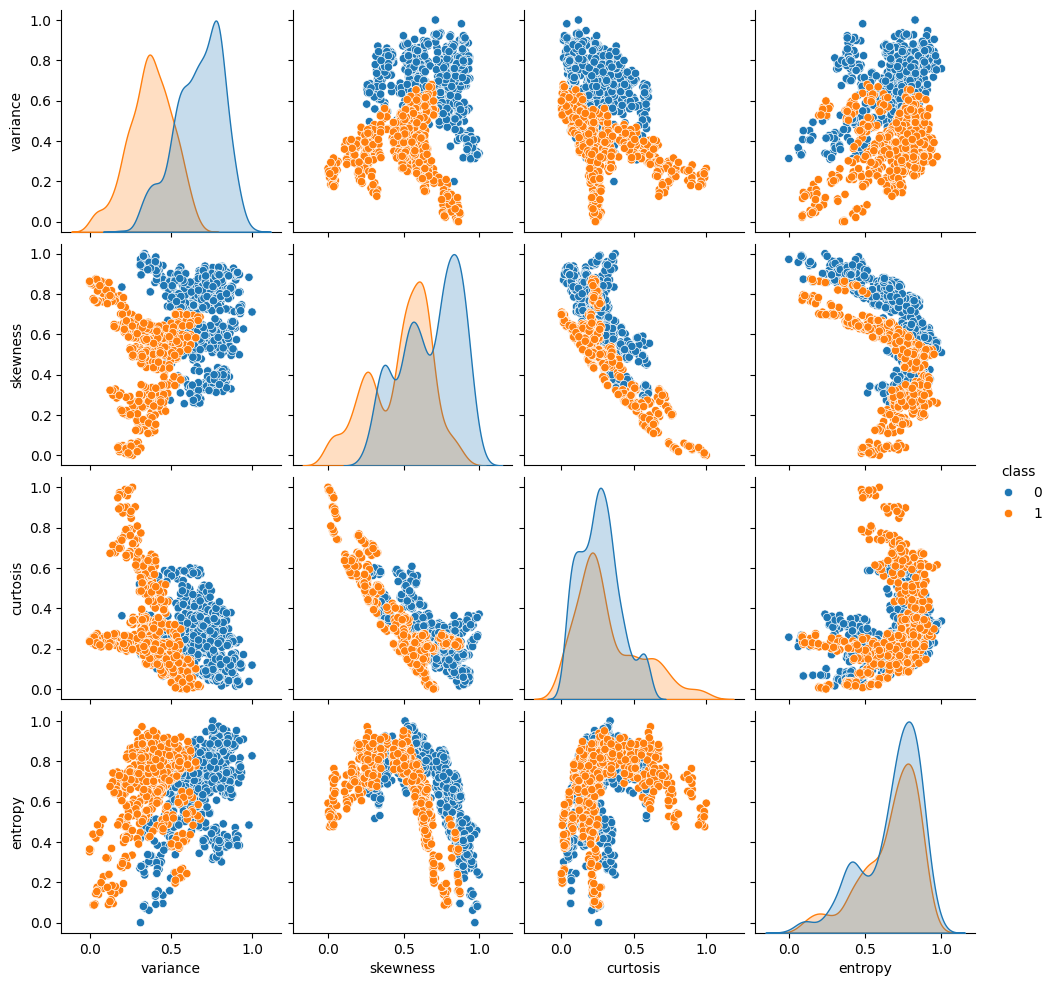

In [27]:
# The Banknote Authentication feature names
feature_names = ["variance", "skewness", "curtosis", "entropy"]

# Create DataFrame for analysis
df = pd.DataFrame(features, columns=feature_names)
df["class"] = labels

# Visualize with Seaborn
sns.pairplot(df, hue="class", palette="tab10")

In [28]:
df.head()

,variance,skewness,curtosis,entropy,class
0,0.769004,0.839643,0.106783,0.736628,0
1,0.835659,0.820982,0.121804,0.644326,0
2,0.786629,0.416648,0.310608,0.786951,0
3,0.757105,0.871699,0.054921,0.450440,0
4,0.531578,0.348662,0.424662,0.687362,0


In [29]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.539114,0.587301,0.287924,0.668917,0.444606
std,0.205003,0.219611,0.185669,0.191041,0.497103
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.379977,0.451451,0.159869,0.557821,0.000000
50%,0.543617,0.602168,0.254280,0.723929,0.000000
75%,0.711304,0.770363,0.364674,0.813171,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Split into train and test sets
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, random_state=123
)

# Initialize and train the Classical SVC
svc = SVC()
svc.fit(train_features, train_labels)

# Evaluate the model
train_score = svc.score(train_features, train_labels)
test_score = svc.score(test_features, test_labels)

print(f"Classical SVC on the training dataset: {train_score:.2f}")
print(f"Classical SVC on the test dataset: {test_score:.2f}")

Classical SVC on the training dataset: 1.00
Classical SVC on the test dataset: 0.99


## Classical classifier:

## Exercise 1:
Use the same method to create machine learning model for the following dataset https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html